# Insect Keypoint Detection
This notebook trains a deep learning model to detect anatomical keypoints on insect images.

**Pipeline overview:**
1. Load & explore the JSON annotation file
2. Build a PyTorch `Dataset` and `DataLoader`
3. Define a ResNet-50 backbone + keypoint regression head
4. Train with MSE loss and evaluate with PCK metric
5. Visualise predictions
6. Compare alternative architectures

---
> **Adapt the three variables in Section 1** (`JSON_PATH`, `IMAGE_BASE_DIR`, `KEYPOINT_NAMES`) to match your dataset.

## 0 · Install dependencies

In [35]:
# Run once – restart kernel afterwards if needed
#!pip install torch torchvision albumentations opencv-python-headless matplotlib tqdm 

## 1 · Configuration

In [36]:
import os, json, random, math
from pathlib import Path

# ─── USER SETTINGS ────────────────────────────────────────────────────────────
JSON_PATH        = "../annotations/test_coco.json"   # path to your annotation file
IMAGE_BASE_DIR   = "../databases/hawaii_beetles_images/individual_specimens/01/"            # root folder containing images
                                         # (ignored if your JSON stores full URLs)

# List of keypoint names IN ORDER as they appear in your annotation file
KEYPOINT_NAMES = [
    "head-top",
    "head-left",
    "head-right",
    "left-eye",
    "right-eye",
    "neck",
    "thorax-left",
    "thorax-right",
    "thorax-bottom",
    "body-left",
    "body-right",
    "body-tip",
    "left-antenna-0",
    "left-antenna-1",
    "left-antenna-2",
    "right-antenna-0",
    "right-antenna-1",
    "right-antenna-2",
    "left-forewing-base",
    "left-forewing-tip",
    "left-forewing-front",
    "left-forewing-rear",
    "right-forewing-base",
    "right-forewing-tip",
    "right-forewing-front",
    "right-forewing-rear",
    "left-hindwing-base",
    "left-hindwing-tip",
    "left-hindwing-front",
    "left-hindwing-rear",
    "right-hindwing-base",
    "right-hindwing-tip",
    "right-hindwing-front",
    "right-hindwing-rear",
    "left-leg-0",
    "left-leg-1",
    "left-leg-2",
    "left-leg-3",
    "right-leg-0",
    "right-leg-1",
    "right-leg-2",
    "right-leg-3",
]
# ──────────────────────────────────────────────────────────────────────────────

NUM_KEYPOINTS  = len(KEYPOINT_NAMES)
IMG_SIZE       = 256        # square resize target
BATCH_SIZE     = 16
NUM_EPOCHS     = 200
LR             = 1e-4
VAL_SPLIT      = 0.15
TEST_SPLIT     = 0.10
SEED           = 42
DEVICE         = "cuda" if __import__('torch').cuda.is_available() else "cpu"

print(f"Keypoints : {NUM_KEYPOINTS}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Device    : {DEVICE}")

Keypoints : 42
Image size: 256x256
Device    : cpu


## 2 · Load & explore annotations

The loader below handles **two common formats**.

**Format A – flat list** (custom tool output):
```json
[
  {
    "image": "path/to/img.jpg",
    "keypoints": {
      "head":    {"x": 120, "y": 45},
      "thorax":  {"x": 130, "y": 80},
      ...
    }
  },
  ...
]
```

**Format B – COCO-style**:
```json
{
  "images": [{"id": 1, "file_name": "img.jpg", "width": 640, "height": 480}],
  "annotations": [{"image_id": 1, "keypoints": [x1,y1,v1, x2,y2,v2, ...]}]
}
```
*(v = visibility flag: 0 absent, 1 occluded, 2 visible)*

In [37]:
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from urllib.request import urlretrieve

def load_annotations(json_path: str, image_base_dir: str, kp_names: list) -> list:
    """
    Returns a list of dicts:
        {"image_path": str,
         "keypoints": np.ndarray shape (N,2),   # x,y in pixel coords
         "visibility": np.ndarray shape (N,)    # 0/1
        }
    """
    with open(json_path) as f:
        raw = json.load(f)

    samples = []

    # ── Format B: COCO-style ──────────────────────────────────────────────────
    if isinstance(raw, dict) and "images" in raw and "annotations" in raw:
        id2file = {img["id"]: img["file_name"] for img in raw["images"]}
        for ann in raw["annotations"]:
            kp_flat = ann["keypoints"]          # [x1,y1,v1, x2,y2,v2, ...]
            kp_arr  = np.array(kp_flat, dtype=np.float32).reshape(-1, 3)
            coords     = kp_arr[:, :2]           # (N,2)
            visibility = (kp_arr[:, 2] > 0).astype(np.float32)  # (N,)
            img_file   = id2file[ann["image_id"]]
            
            img_file = "".join(img_file.split("-")[1:])
            img_path   = os.path.join(image_base_dir, img_file)
            samples.append({"image_path": img_path,
                             "keypoints":  coords,
                             "visibility": visibility})

    # ── Format A: flat list ───────────────────────────────────────────────────
    elif isinstance(raw, list):
        for item in raw:
            img_val = item.get("image") or item.get("file_name") or item.get("url")
            # Support remote URLs or local paths
            if img_val.startswith("http"):
                img_path = img_val          # will be downloaded on-the-fly
            else:
                img_path = os.path.join(image_base_dir, img_val)

            kp_dict = item.get("keypoints", {})
            coords     = np.zeros((len(kp_names), 2), dtype=np.float32)
            visibility = np.zeros(len(kp_names),      dtype=np.float32)

            for i, name in enumerate(kp_names):
                if name in kp_dict and kp_dict[name] is not None:
                    pt = kp_dict[name]
                    if isinstance(pt, dict):
                        coords[i]     = [pt["x"], pt["y"]]
                        visibility[i] = pt.get("visibility", 1)
                    else:                                   # [x, y] list
                        coords[i]     = pt[:2]
                        visibility[i] = pt[2] if len(pt) > 2 else 1

            samples.append({"image_path": img_path,
                             "keypoints":  coords,
                             "visibility": visibility})
    else:
        raise ValueError("Unrecognised JSON format. See cell above for supported formats.")

    return samples


samples = load_annotations(JSON_PATH, IMAGE_BASE_DIR, KEYPOINT_NAMES)
print(f"Total annotated images: {len(samples)}")

# Visibility stats
all_vis = np.stack([s["visibility"] for s in samples])
print("\nKeypoint visibility rate (% of images where the point is annotated):")
for name, rate in zip(KEYPOINT_NAMES, all_vis.mean(axis=0) * 100):
    bar = '█' * int(rate / 5)
    print(f"  {name:<20} {rate:5.1f}%  {bar}")

Total annotated images: 96

Keypoint visibility rate (% of images where the point is annotated):
  head-top             100.0%  ████████████████████
  head-left            100.0%  ████████████████████
  head-right           100.0%  ████████████████████
  left-eye             100.0%  ████████████████████
  right-eye            100.0%  ████████████████████
  neck                 100.0%  ████████████████████
  thorax-left          100.0%  ████████████████████
  thorax-right         100.0%  ████████████████████
  thorax-bottom        100.0%  ████████████████████
  body-left            100.0%  ████████████████████
  body-right           100.0%  ████████████████████
  body-tip             100.0%  ████████████████████
  left-antenna-0       100.0%  ████████████████████
  left-antenna-1       100.0%  ████████████████████
  left-antenna-2       100.0%  ████████████████████
  right-antenna-0      100.0%  ████████████████████
  right-antenna-1      100.0%  ████████████████████
  right-antenna-2  

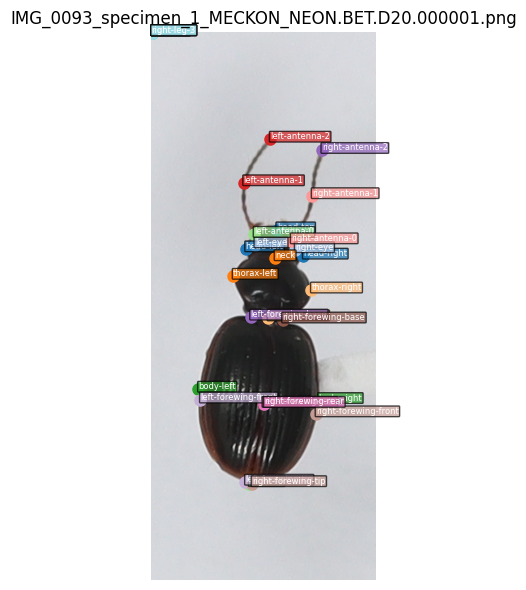

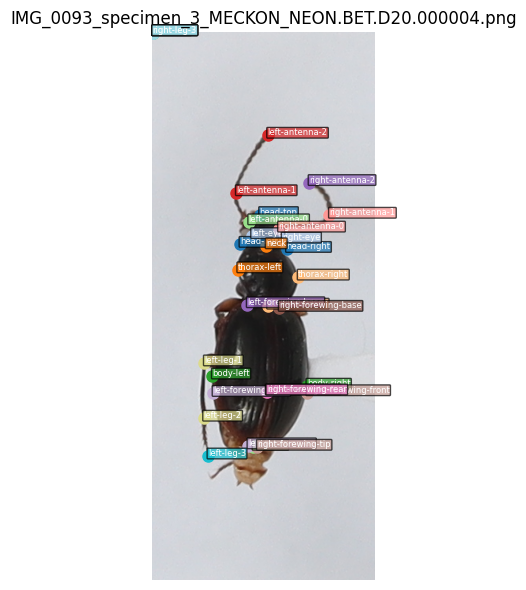

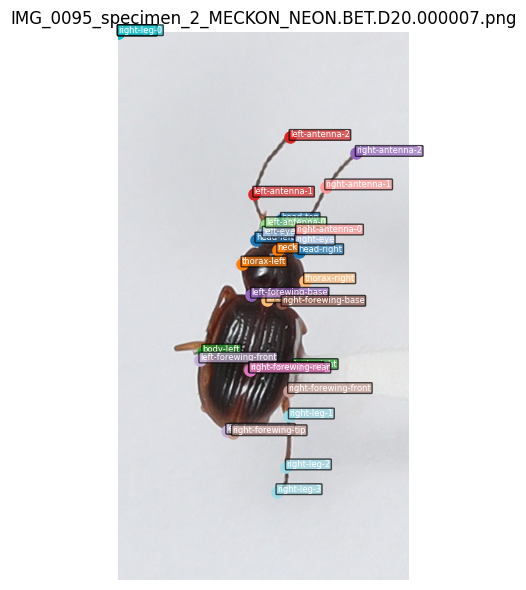

In [38]:
def read_image(path_or_url: str) -> np.ndarray:
    """Load an image (local file or remote URL) as RGB numpy array."""
    if path_or_url.startswith("http"):
        import tempfile, urllib.request
        ext  = Path(path_or_url).suffix or ".jpg"
        tmp  = tempfile.NamedTemporaryFile(suffix=ext, delete=False)
        urllib.request.urlretrieve(path_or_url, tmp.name)
        img  = cv2.imread(tmp.name)
    else:
        img = cv2.imread(path_or_url)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path_or_url}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def visualise_sample(sample: dict, kp_names: list, title: str = ""):
    img = read_image(sample["image_path"])
    h, w = img.shape[:2]
    coords  = sample["keypoints"]
    visible = sample["visibility"]

    cmap = plt.get_cmap("tab20", len(kp_names))
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img)
    for i, (name, vis) in enumerate(zip(kp_names, visible)):
        if vis > 0:
            x, y = coords[i]
            color = cmap(i)
            ax.plot(x, y, 'o', color=color, markersize=8, label=name)
            ax.annotate(name, (x, y), fontsize=6, color='white',
                        bbox=dict(boxstyle='round,pad=0.1', fc=color, alpha=0.7))
    ax.set_title(title or Path(sample["image_path"]).name)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Show first 3 samples
for s in samples[:3]:
    visualise_sample(s, KEYPOINT_NAMES)

## 3 · Dataset & data augmentation

In [39]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset, DataLoader, Subset

# ── Augmentation pipelines ────────────────────────────────────────────────────
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def make_transforms(split: str, img_size: int):
    """
    Albumentations pipeline that handles keypoints automatically.
    `split` is one of 'train', 'val', 'test'
    """
    kp_params = A.KeypointParams(
        format='xy',
        remove_invisible=False,   # keep invisible kpts at (0,0)
        angle_in_degrees=True
    )
    shared = [
        A.LongestMaxSize(max_size=img_size),
        A.PadIfNeeded(min_height=img_size, min_width=img_size,
                      border_mode=cv2.BORDER_CONSTANT, value=0),
    ]
    if split == 'train':
        augmentations = [
            # A.HorizontalFlip(p=0.5),
            A.Rotate(limit=30, p=0.6),
            A.RandomBrightnessContrast(p=0.4),
            A.HueSaturationValue(p=0.3),
            A.GaussNoise(p=0.2),
            A.Blur(blur_limit=3, p=0.2),
            A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.2),
        ]
    else:
        augmentations = []

    normalise = [
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ]
    return A.Compose(shared + augmentations + normalise,
                     keypoint_params=kp_params)


# ── Dataset class ─────────────────────────────────────────────────────────────
class InsectKeypointDataset(Dataset):
    def __init__(self, samples: list, kp_names: list,
                 img_size: int, split: str = 'train'):
        self.samples   = samples
        self.kp_names  = kp_names
        self.img_size  = img_size
        self.transform = make_transforms(split, img_size)
        self.n_kp      = len(kp_names)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img    = read_image(sample["image_path"])
        coords = sample["keypoints"].copy()    # (N, 2)  pixel coords
        vis    = sample["visibility"].copy()   # (N,)

        # Clip coords to image bounds to satisfy albumentations
        h, w = img.shape[:2]
        coords[:, 0] = np.clip(coords[:, 0], 0, w - 1)
        coords[:, 1] = np.clip(coords[:, 1], 0, h - 1)

        # Run augmentation
        kp_list = [(x, y) for x, y in coords]
        result  = self.transform(image=img, keypoints=kp_list)
        img_t   = result["image"]                        # (3, H, W) tensor

        # Recover keypoints (albumentations may clip them)
        out_kps = np.zeros((self.n_kp, 2), dtype=np.float32)
        for i, pt in enumerate(result["keypoints"]):
            out_kps[i] = pt[:2]

        # Normalise coords to [0, 1]
        out_kps /= self.img_size

        return (
            img_t,
            torch.tensor(out_kps,  dtype=torch.float32),   # (N, 2)
            torch.tensor(vis,      dtype=torch.float32),   # (N,)
        )

print("Dataset class ready.")

Dataset class ready.


In [40]:
# ── Train / Val / Test split ──────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)

indices = list(range(len(samples)))
random.shuffle(indices)

n_test  = max(1, int(len(indices) * TEST_SPLIT))
n_val   = max(1, int(len(indices) * VAL_SPLIT))

test_idx  = indices[:n_test]
val_idx   = indices[n_test : n_test + n_val]
train_idx = indices[n_test + n_val :]

print(f"Split  →  train: {len(train_idx)}  val: {len(val_idx)}  test: {len(test_idx)}")

train_samples = [samples[i] for i in train_idx]
val_samples   = [samples[i] for i in val_idx]
test_samples  = [samples[i] for i in test_idx]

train_ds = InsectKeypointDataset(train_samples, KEYPOINT_NAMES, IMG_SIZE, 'train')
val_ds   = InsectKeypointDataset(val_samples,   KEYPOINT_NAMES, IMG_SIZE, 'val')
test_ds  = InsectKeypointDataset(test_samples,  KEYPOINT_NAMES, IMG_SIZE, 'test')

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Sanity-check one batch
imgs, kps, vis = next(iter(train_dl))
print(f"Batch  →  imgs: {imgs.shape}  kps: {kps.shape}  vis: {vis.shape}")

Split  →  train: 73  val: 14  test: 9


C:\Users\tombe\AppData\Local\Temp\ipykernel_15820\2447819212.py:22: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=img_size, min_width=img_size,
C:\Users\tombe\AppData\Local\Temp\ipykernel_15820\2447819212.py:33: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.2),
c:\Users\tombe\Documents\_MLE\CV-for-GRIT\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch  →  imgs: torch.Size([16, 3, 256, 256])  kps: torch.Size([16, 42, 2])  vis: torch.Size([16, 42])


## 4 · Model — ResNet-50 backbone + keypoint regression head

A pretrained **ResNet-50** acts as a feature extractor. Its classification head is replaced by a lightweight MLP that directly regresses `(x, y)` coordinates for each keypoint, normalised to [0, 1].

In [41]:
import torch
import torch.nn as nn
import torchvision.models as models

class InsectKeypointModel(nn.Module):
    """
    ResNet-50 encoder + MLP regressor.
    Output: (B, N, 2)  normalised keypoint coords in [0,1].
    """
    def __init__(self, num_keypoints: int, pretrained: bool = True):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        backbone = models.resnet50(weights=weights)

        # Keep everything except the final FC layer
        self.encoder = nn.Sequential(*list(backbone.children())[:-1])  # → (B, 2048, 1, 1)

        # Regressor head
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_keypoints * 2),
            nn.Sigmoid(),   # constrain output to [0, 1]
        )
        self.num_keypoints = num_keypoints

    def forward(self, x):
        feats = self.encoder(x)           # (B, 2048, 1, 1)
        out   = self.head(feats)          # (B, N*2)
        return out.view(-1, self.num_keypoints, 2)  # (B, N, 2)


model = InsectKeypointModel(num_keypoints=NUM_KEYPOINTS).to(DEVICE)

# Quick forward pass check
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f"Output shape: {out.shape}   (expected: [2, {NUM_KEYPOINTS}, 2])")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Output shape: torch.Size([2, 42, 2])   (expected: [2, 42, 2])
Trainable parameters: 24,710,036


## 5 · Loss, optimiser & scheduler

We use a **weighted MSE** that ignores invisible keypoints. The weight per point is its visibility flag (0 or 1).

In [42]:
def weighted_mse_loss(pred: torch.Tensor,
                      target: torch.Tensor,
                      visibility: torch.Tensor) -> torch.Tensor:
    """
    pred, target : (B, N, 2)
    visibility   : (B, N)    — 1 if annotated, 0 if missing
    """
    w   = visibility.unsqueeze(-1)              # (B, N, 1)
    sq  = (pred - target) ** 2                 # (B, N, 2)
    loss = (w * sq).sum() / (w.sum() * 2 + 1e-6)
    return loss


optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print("Loss function and optimiser ready.")

Loss function and optimiser ready.


## 6 · PCK metric — Percentage of Correct Keypoints

A keypoint is *correct* if its predicted position is within a threshold distance from the ground-truth. Here we use **PCK@0.1** (threshold = 10% of the image diagonal).

In [43]:
def pck(pred: torch.Tensor,
        target: torch.Tensor,
        visibility: torch.Tensor,
        threshold: float = 0.01) -> float:
    """
    Percentage of Correct Keypoints @ `threshold`.
    Coords are normalised [0,1]; diagonal = sqrt(2) ≈ 1.414.
    """
    diag    = math.sqrt(2.0)
    dist    = torch.norm(pred - target, dim=-1)          # (B, N)
    correct = (dist < threshold * diag).float()          # (B, N)
    mask    = visibility > 0                             # (B, N)
    if mask.sum() == 0:
        return float('nan')
    return (correct[mask]).mean().item() * 100

print("PCK metric ready.")

PCK metric ready.


## 7 · Training loop

In [44]:
from tqdm.notebook import tqdm

history = {"train_loss": [], "val_loss": [], "val_pck": []}
best_val_loss = float("inf")
CKPT_PATH = "best_insect_keypoint.pth"

def run_epoch(loader, model, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, total_pck, n_batches = 0.0, 0.0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, kps, vis in loader:
            imgs = imgs.to(DEVICE)
            kps  = kps.to(DEVICE)
            vis  = vis.to(DEVICE)

            pred = model(imgs)
            loss = weighted_mse_loss(pred, kps, vis)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            total_pck  += pck(pred.detach(), kps, vis)
            n_batches  += 1

    return total_loss / n_batches, total_pck / n_batches


for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, _       = run_epoch(train_dl, model, optimizer, train=True)
    vl_loss, vl_pck  = run_epoch(val_dl,   model, train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["val_pck"].append(vl_pck)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), CKPT_PATH)
        tag = "✓ saved"
    else:
        tag = ""

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS}  "
              f"loss: {tr_loss:.4f} → val: {vl_loss:.4f}  "
              f"PCK@0.1: {vl_pck:.1f}%  {tag}")

print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch   1/200  loss: 0.0498 → val: 0.0489  PCK@0.1: 0.2%  ✓ saved
Epoch   5/200  loss: 0.0250 → val: 0.0235  PCK@0.1: 1.5%  ✓ saved
Epoch  10/200  loss: 0.0198 → val: 0.0207  PCK@0.1: 2.5%  
Epoch  15/200  loss: 0.0174 → val: 0.0207  PCK@0.1: 2.1%  
Epoch  20/200  loss: 0.0187 → val: 0.0204  PCK@0.1: 1.7%  
Epoch  25/200  loss: 0.0170 → val: 0.0203  PCK@0.1: 1.9%  
Epoch  30/200  loss: 0.0159 → val: 0.0190  PCK@0.1: 3.2%  ✓ saved
Epoch  35/200  loss: 0.0152 → val: 0.0195  PCK@0.1: 5.0%  
Epoch  40/200  loss: 0.0134 → val: 0.0187  PCK@0.1: 2.9%  ✓ saved
Epoch  45/200  loss: 0.0123 → val: 0.0183  PCK@0.1: 2.5%  
Epoch  50/200  loss: 0.0119 → val: 0.0184  PCK@0.1: 4.8%  
Epoch  55/200  loss: 0.0106 → val: 0.0184  PCK@0.1: 4.0%  
Epoch  60/200  loss: 0.0104 → val: 0.0175  PCK@0.1: 6.5%  ✓ saved
Epoch  65/200  loss: 0.0101 → val: 0.0167  PCK@0.1: 4.8%  ✓ saved
Epoch  70/200  loss: 0.0091 → val: 0.0180  PCK@0.1: 4.6%  
Epoch  75/200  loss: 0.0088 → val: 0.0169  PCK@0.1: 6.3%  
Epoch  80/200 

## 8 · Training curves

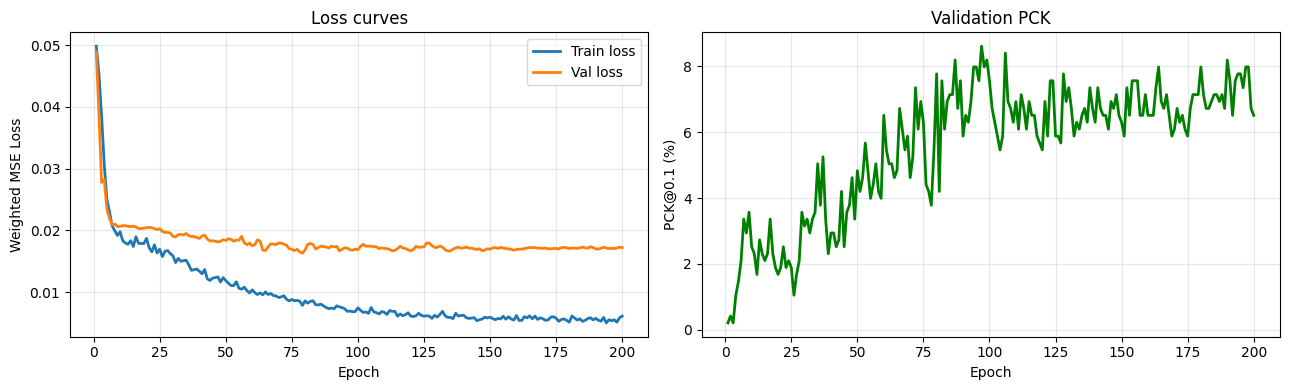

In [49]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs, history["train_loss"], label="Train loss", linewidth=2)
ax1.plot(epochs, history["val_loss"],   label="Val loss",   linewidth=2)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Weighted MSE Loss")
ax1.set_title("Loss curves"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history["val_pck"], color="green", linewidth=2)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("PCK@0.1 (%)")
ax2.set_title("Validation PCK"); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

## 9 · Test-set evaluation

In [50]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_targets, all_vis = [], [], []

with torch.no_grad():
    for imgs, kps, vis in test_dl:
        pred = model(imgs.to(DEVICE))
        all_preds.append(pred.cpu())
        all_targets.append(kps)
        all_vis.append(vis)

all_preds   = torch.cat(all_preds)    # (total_test, N, 2)
all_targets = torch.cat(all_targets)
all_vis     = torch.cat(all_vis)

for thresh in [0.01, 0.05, 0.10, 0.15, 0.20]:
    score = pck(all_preds, all_targets, all_vis, threshold=thresh)
    print(f"  PCK@{thresh:.2f} : {score:.2f}%")

# Per-keypoint PCK@0.10
print("\nPer-keypoint PCK@0.10:")
diag = math.sqrt(2)
dist = torch.norm(all_preds - all_targets, dim=-1)   # (T, N)
mask = all_vis > 0
for i, name in enumerate(KEYPOINT_NAMES):
    m = mask[:, i]
    if m.sum() == 0:
        print(f"  {name:<20}  N/A")
    else:
        correct = (dist[:, i][m] < 0.10 * diag).float().mean().item() * 100
        bar = '█' * int(correct / 5)
        print(f"  {name:<20}  {correct:5.1f}%  {bar}")

  PCK@0.01 : 9.80%
  PCK@0.05 : 69.61%
  PCK@0.10 : 84.97%
  PCK@0.15 : 90.85%
  PCK@0.20 : 93.46%

Per-keypoint PCK@0.10:
  head-top              100.0%  ████████████████████
  head-left             100.0%  ████████████████████
  head-right            100.0%  ████████████████████
  left-eye               88.9%  █████████████████
  right-eye              88.9%  █████████████████
  neck                  100.0%  ████████████████████
  thorax-left           100.0%  ████████████████████
  thorax-right          100.0%  ████████████████████
  thorax-bottom         100.0%  ████████████████████
  body-left              88.9%  █████████████████
  body-right             88.9%  █████████████████
  body-tip              100.0%  ████████████████████
  left-antenna-0        100.0%  ████████████████████
  left-antenna-1        100.0%  ████████████████████
  left-antenna-2         77.8%  ███████████████
  right-antenna-0       100.0%  ████████████████████
  right-antenna-1       100.0%  ██████████████

## 10 · Visualise predictions on test images

C:\Users\tombe\AppData\Local\Temp\ipykernel_15820\2447819212.py:22: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=img_size, min_width=img_size,


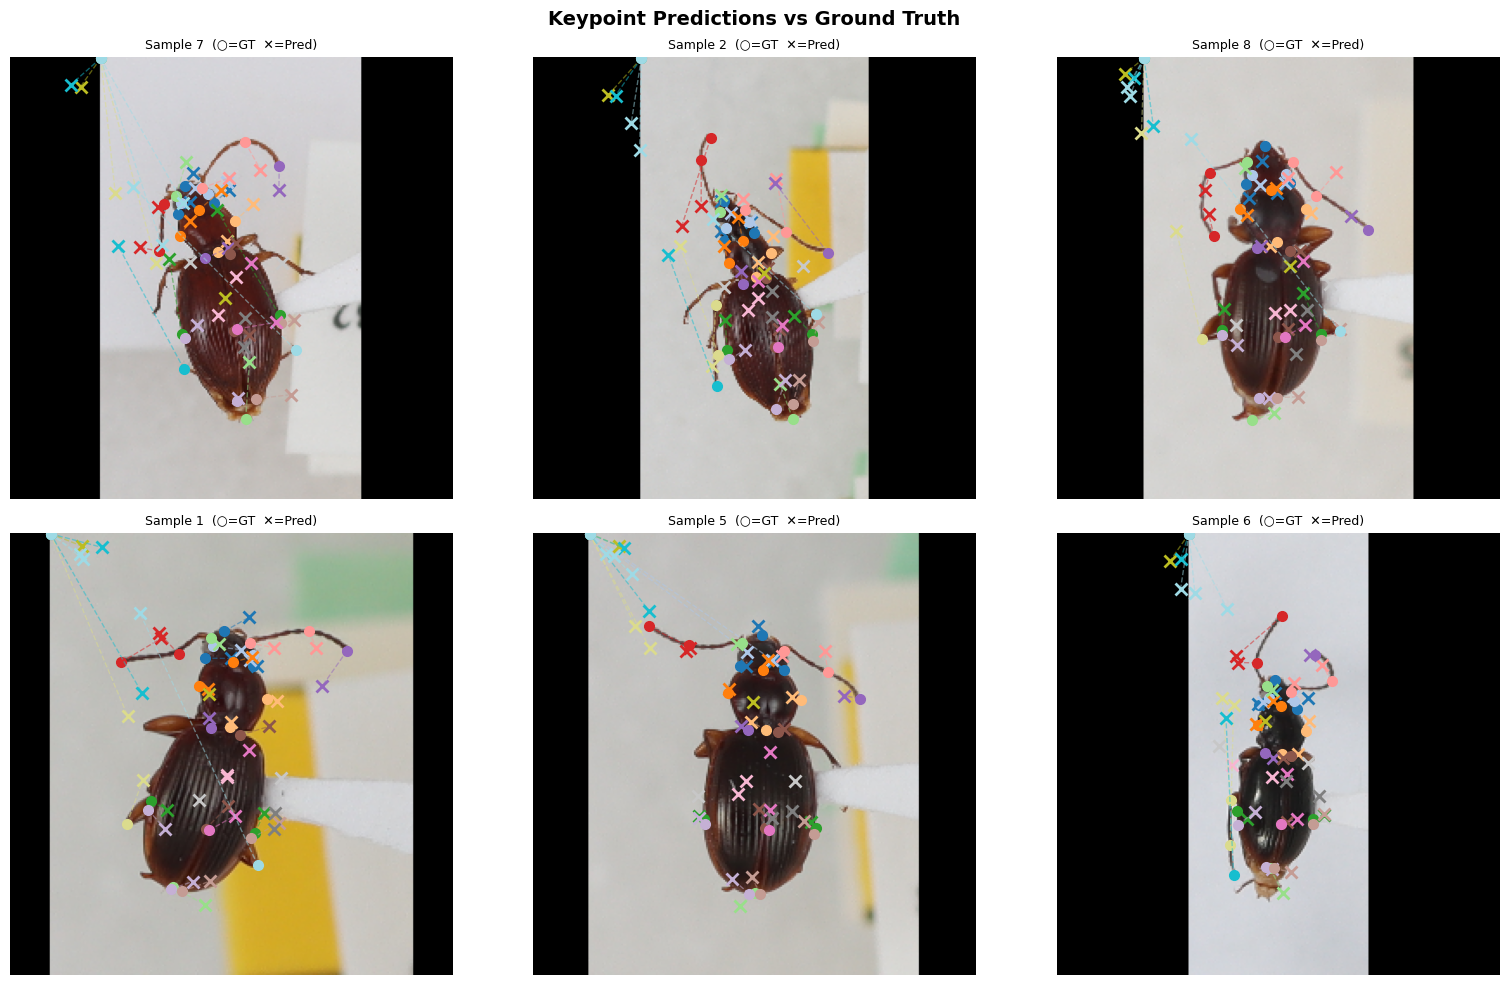

In [51]:
def visualise_predictions(model, samples, kp_names, img_size,
                           n_examples=6, device="cpu"):
    model.eval()
    ds = InsectKeypointDataset(samples, kp_names, img_size, split='test')
    cmap = plt.get_cmap("tab20", len(kp_names))

    indices = random.sample(range(len(ds)), min(n_examples, len(ds)))
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for ax_idx, sample_idx in enumerate(indices):
        img_t, gt_kps, vis = ds[sample_idx]

        with torch.no_grad():
            pred_kps = model(img_t.unsqueeze(0).to(device)).squeeze(0).cpu().numpy()

        gt_kps = gt_kps.numpy()
        vis    = vis.numpy()

        # Denormalise image for display
        mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
        std  = np.array(IMAGENET_STD).reshape(3, 1, 1)
        img_disp = img_t.numpy() * std + mean
        img_disp = np.clip(img_disp.transpose(1, 2, 0), 0, 1)

        ax = axes[ax_idx]
        ax.imshow(img_disp)
        for i, name in enumerate(kp_names):
            color = cmap(i)
            gx, gy = gt_kps[i] * img_size, gt_kps[i, 1] * img_size  # BUG-SAFE
            gx, gy = gt_kps[i, 0] * img_size, gt_kps[i, 1] * img_size
            px, py = pred_kps[i, 0] * img_size, pred_kps[i, 1] * img_size
            if vis[i] > 0:
                ax.plot(gx, gy, 'o', color=color,  markersize=7, label=f"{name} GT")
            ax.plot(px, py, 'x', color=color,  markersize=9, markeredgewidth=2)
            if vis[i] > 0:
                ax.plot([gx, px], [gy, py], '--', color=color, alpha=0.5, linewidth=1)
        ax.set_title(f"Sample {sample_idx}  (○=GT  ✕=Pred)", fontsize=9)
        ax.axis('off')

    plt.suptitle("Keypoint Predictions vs Ground Truth", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("predictions.png", dpi=150)
    plt.show()


visualise_predictions(model, test_samples, KEYPOINT_NAMES, IMG_SIZE, device=DEVICE)

## 11 · Save & export the model

In [48]:
# ── Save full model (weights + config) ───────────────────────────────────────
torch.save({
    "model_state": model.state_dict(),
    "num_keypoints": NUM_KEYPOINTS,
    "keypoint_names": KEYPOINT_NAMES,
    "img_size": IMG_SIZE,
    "best_val_loss": best_val_loss,
}, "insect_keypoint_full.pth")

# ── Export to ONNX (for deployment / inference engines) ───────────────────────
# model.eval()
# dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
# torch.onnx.export(
#     model, dummy_input,
#     "insect_keypoint.onnx",
#     input_names=["image"],
#     output_names=["keypoints"],
#     dynamic_axes={"image": {0: "batch_size"}, "keypoints": {0: "batch_size"}},
#     opset_version=17,
# )
print("Model saved: insect_keypoint_full.pth")
# print("ONNX exported: insect_keypoint.onnx")

Model saved: insect_keypoint_full.pth


---
## 12 · Alternative architectures — comparison

Below is a structured comparison of state-of-the-art approaches for keypoint detection. For each architecture we outline its principle, its strengths, and its limitations **in the context of a small insect dataset**.

---

### 12.1 · ResNet / EfficientNet + regression head *(this notebook)*

| | |
|---|---|
| **Principle** | Pretrained CNN encoder → Global Average Pooling → MLP that directly regresses normalised `(x, y)` coordinates. |
| **✅ Pros** | Simple to implement and debug; very few moving parts; transfers well from ImageNet; fast inference. |
| **❌ Cons** | Global pooling destroys spatial information — the model has no notion of *where* in the image a point lives; hard to localise fine-grained landmarks precisely; struggles with small datasets if points cluster. |
| **Best for** | Baseline / proof-of-concept; rapid iteration; when you have < 500 images. |

---

### 12.2 · Heatmap-based CNN (SimpleBaseline / HRNet)

| | |
|---|---|
| **Principle** | Instead of regressing coordinates, predict one **Gaussian heatmap** per keypoint (a spatial confidence map). The argmax of the heatmap gives the predicted position. **HRNet** maintains high-resolution feature maps throughout the backbone by running parallel sub-networks at multiple scales. |
| **✅ Pros** | Spatially aware — heatmaps exploit local texture; state-of-the-art accuracy on COCO; handles occlusion gracefully; per-keypoint uncertainty is implicit in the heatmap peak. |
| **❌ Cons** | Requires a decoder / upsampling branch (U-Net style) → more memory and compute; output heatmap resolution limits precision (typically stride 4); more complex to train; needs larger datasets to shine. |
| **Best for** | When precision matters and you have 1 000+ annotated images. HRNet is the de-facto standard for biological landmark detection. |
| **Libraries** | `mmpose`, `timm` |

---

### 12.3 · YOLO-Pose (YOLOv8-pose / YOLOv9-pose)

| | |
|---|---|
| **Principle** | Extends a single-stage YOLO detector to jointly predict a bounding box **and** keypoints for each detected instance in a single forward pass. Keypoints are regressed from the detection grid. |
| **✅ Pros** | Extremely fast (real-time on GPU and even CPU); handles multiple insects in one image naturally; a single model handles detection + keypoints; great Ultralytics ecosystem with easy fine-tuning API. |
| **❌ Cons** | Designed for human pose (17 joints); fine-tuning on a custom skeleton requires modifying the model config; can miss very small insects; accuracy lags behind HRNet at equal dataset size. |
| **Best for** | Multi-instance detection (many insects per frame); video / real-time; when you already use YOLO in your pipeline. |
| **Code** | `from ultralytics import YOLO; model = YOLO("yolov8n-pose.pt")` |

---

### 12.4 · DeepLabCut

| | |
|---|---|
| **Principle** | A full end-to-end **GUI + training + analysis** toolkit designed specifically for animal body-part tracking. Uses a ResNet or EfficientNet backbone with a deconvolution head to produce heatmaps. The GUI makes annotation and fine-tuning interactive. |
| **✅ Pros** | Purpose-built for animals and insects; excellent active-learning workflow (label a few frames, train, check, repeat); built-in temporal tracking for video; large community in neuroscience / entomology; no deep-learning expertise needed to operate. |
| **❌ Cons** | Less flexible as a library (harder to integrate into custom pipelines); GUI is heavyweight; fine-tuning from scratch requires CUDA; not ideal if your data is static images (it shines on video). |
| **Best for** | Behavioural neuroscience / entomology video tracking; teams without ML expertise; iterative annotation workflows. |
| **Docs** | https://deeplabcut.github.io/DeepLabCut |

---

### 12.5 · ViTPose (Vision Transformer)

| | |
|---|---|
| **Principle** | Uses a **plain ViT** (Vision Transformer) encoder pretrained with MAE (masked autoencoder), followed by a simple decoder that outputs keypoint heatmaps. No convolutional inductive bias. |
| **✅ Pros** | State-of-the-art on COCO; excellent long-range reasoning (global attention); scales well with more data and compute; a single backbone serves multiple pose tasks via adapter modules. |
| **❌ Cons** | Very compute-hungry (ViT-H needs 32 GB+ GPU to fine-tune); pre-training requires massive data; overkill for small insect datasets; slower inference than CNNs. |
| **Best for** | Large-scale datasets (10k+ images); research settings with access to powerful GPUs. |
| **Paper** | ViTPose: Simple Vision Transformer Baselines for Human Pose Estimation (2022) |

---

### 12.6 · RTMPose

| | |
|---|---|
| **Principle** | A fast heatmap-based detector from OpenMMLab, specifically optimised for real-time mobile and edge deployment. Uses a CSPNeXt backbone and a token-based head. |
| **✅ Pros** | Excellent speed-accuracy trade-off; works on CPU; full `mmpose` integration; easy to customise skeleton. |
| **❌ Cons** | Still requires careful config editing in mmpose; smaller community than YOLO-pose. |
| **Best for** | Edge / embedded deployment; production systems where YOLO-pose accuracy is insufficient. |

---

### Summary table

| Model | Accuracy | Speed | Small dataset | Multi-instance | Ease of use |
|-------|----------|-------|--------------|----------------|-------------|
| ResNet + regression | ★★★☆☆ | ★★★★★ | ★★★★★ | ★★☆☆☆ | ★★★★★ |
| HRNet / heatmap | ★★★★★ | ★★★☆☆ | ★★★☆☆ | ★★★☆☆ | ★★★☆☆ |
| YOLO-pose | ★★★★☆ | ★★★★★ | ★★★★☆ | ★★★★★ | ★★★★☆ |
| DeepLabCut | ★★★★☆ | ★★★☆☆ | ★★★★★ | ★★☆☆☆ | ★★★★★ |
| ViTPose | ★★★★★ | ★★☆☆☆ | ★★☆☆☆ | ★★★☆☆ | ★★☆☆☆ |
| RTMPose | ★★★★☆ | ★★★★★ | ★★★☆☆ | ★★★☆☆ | ★★★☆☆ |

---

### Recommendation for insect datasets

* **< 500 images** → start with this notebook (ResNet regression) + **DeepLabCut** for an easy iterative labelling loop.
* **500 – 5 000 images** → switch to **YOLO-pose** (easiest to fine-tune) or **HRNet** via `mmpose` for maximum accuracy.
* **> 5 000 images** → **ViTPose** or **HRNet-W48** will give the best results.
* **Video tracking** → **DeepLabCut** is unbeatable out of the box.